# NetFlix Movie Dataset - Data Cleaning & EDA

## Task 1 Dataset Understanding

In [24]:
import pandas as pd 
df = pd.read_csv("netflix_titles.csv")
df.head()
import os
os.makedirs("visuals", exist_ok=True)

This dataset contains 8807 Netflix titles with 12 attributes covering title metadata, cast/rew, country, ratings and content categorization. It has one numerical column (release year) and 11 categorical/text columns, with notable data missing in director, cast amd country. show_id is confirmed as the unique identifier (primary key) with 8807 unique values matching the row count.

In [25]:
print(df.shape)

(8807, 12)


In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [27]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [28]:
df['show_id'].nunique()

8807

## Task 2 Data Cleaning

director, cast and country were filled with 'Unknown' to preserve data volume. Rows missing date_added, rating, or duration (13 rows total) were ropped since these are small in number and hard to impute reliably.

In [29]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [30]:
df['director'] = df['director'].fillna("Unknown")
df['cast'] = df['cast'].fillna("Unknown",)
df['country'] = df['country'].fillna("Unknown",)
df = df.dropna(subset=['date_added'])
df = df.dropna(subset=['rating'])
df = df.dropna(subset=['duration'])

No duplicates were found in the dataset

In [31]:
df.duplicated().sum()

np.int64(0)

Column names were already standardized (lowercase, underscore-separated), no changes needed.

In [32]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')

date_added contained incosistent formatting (leading whitespace, and mixed date string formats). Whitespace was stripped and the column converted to proper datetime type using pandas' mixed-format inference

In [33]:
df['date_added'] =df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], format='mixed')

type and rating values were checked for incosistent casing or typos - both columns contained only valid, consistent categories.

In [34]:
df['type'].unique()

array(['Movie', 'TV Show'], dtype=object)

In [35]:
df['rating'].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', 'NR', 'TV-Y7-FV', 'UR'], dtype=object)

Checked for shifted/misaligned data (duration values appearng in rating column) - none found. Rating column is valid.

In [36]:
df[df['rating'].str.contains('min', na=False)]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description


| Issue Found | Action Taken |
|---|---|
| Missing values (director, cast, country) | Filled with "Unknown" |
| Missing values (date_added, rating, duration) | Rows dropped (13 total) |
| Duplicate rows | None found |
| Inconsistent date formats | Standardized to datetime using mixed-format parsing |
| Column names | Already standardized, no changes were made |
| Text casing (type, rating) | Checked, no inconsistencies found |
| Shifted/misaligned data | Checked, none found |

In [37]:
df.to_csv("netflix_cleaned.csv", index=False)

## Task 3 Exploratory Data Analysis 

In [38]:
df.describe(include='object')

,show_id,type,title,director,cast,country,rating,duration,listed_in,description
count,8790,8790,8790,8790,8790,8790,8790,8790,8790,8790
unique,8790,2,8790,4527,7679,749,14,220,513,8758
top,s8807,Movie,Zubaan,Unknown,Unknown,United States,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6126,1,2621,825,2809,3205,1791,362,4


In [39]:
df['type'].value_counts()

type
Movie      6126
TV Show    2664
Name: count, dtype: int64

 **Movies vs TV Shows distribution**

The dataset contains 6,126 movies an 2,664 TV shows; Netflix's catalog is roughly 70% movies and 30% TV shows.

In [40]:
df['date_added'].dt.year.value_counts().sort_index()

date_added
2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     426
2017    1185
2018    1648
2019    2016
2020    1879
2021    1498
Name: count, dtype: int64

**Content added by Year**

Content additions grew sharply from 2016 onward, peaking in 2019 with 2,016 titles added. The slight decline in 2020 - 2021 may reflect pandemic-related production slowdowns or the dataset not capturing the full year.

In [41]:
df['country'].value_counts().head(10)

country
United States     2809
India              972
Unknown            829
United Kingdom     418
Japan              243
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: count, dtype: int64

**Top-content producing countries**

The United States is by far the top content-producing coumtry (2,809 titles), followed by India (972) and the United Kingdom (418). 
'Unknown' ranks fourth due to missing country data filled during cleaning; worth noting this isn't a real country.

In [42]:
df['rating'].value_counts()

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

**Most common ratings**

TV-MA (mature audience) is the most common rating at 3,205 titles, followed by TV-14 (2,157) and TV-PG (861). This suggests Netflix's catalog leanstoward mature/adult content rather than family-friendly programming.

In [43]:
df['listed_in'].str.split(', ').explode().value_counts().head(10)

listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

**Most common genres**

International Movies is the most common genre (2,752), followed by Dramas (2,426) and Comedies (1,674). This reflects Netflix's strong focus on global, non-English-language content alongside core drama/comedy programming.

## Task 4 Visualizations

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

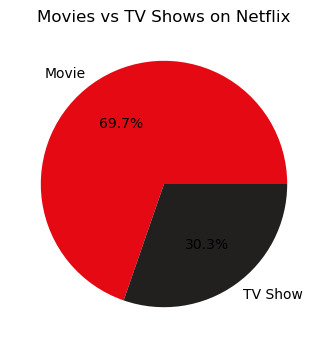

In [45]:
type_counts = df['type'].value_counts()

plt.figure(figsize=(6,4))
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', colors=['#E50914', '#221F1F'])
plt.title("Movies vs TV Shows on Netflix")
plt.savefig("visuals/content_distribution.png")
plt.show()

Netflix's catalog is approximately 69.7% movies and 30.3% TV shows.

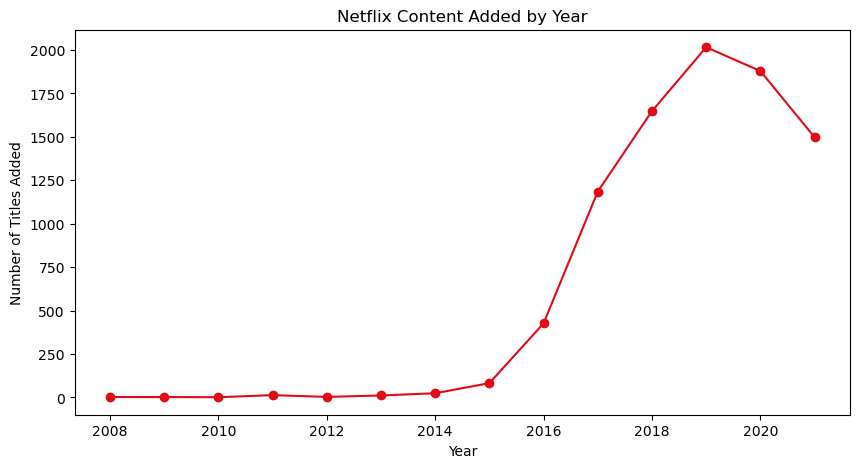

In [46]:
year_counts = df['date_added'].dt.year.value_counts().sort_index()

plt.figure(figsize=(10,5))
plt.plot(year_counts.index, year_counts.values, marker='o', color='#E50914')
plt.title("Netflix Content Added by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.savefig("visuals/content_added_by_year.png")
plt.show()

Netflix's content addition grew slowly through 2015, then surged sharply from 2016 onward - jumping from 82 titles in 2015 to 426 in 2016, and continuing to climb through a peak of 2,016 titles added in 2019. Additions dipped slightly in 2020 (1,879) and 2021 (1,498), which may reflect pandemic-related production delays or the dataset not capturing a full year of data for 2021.

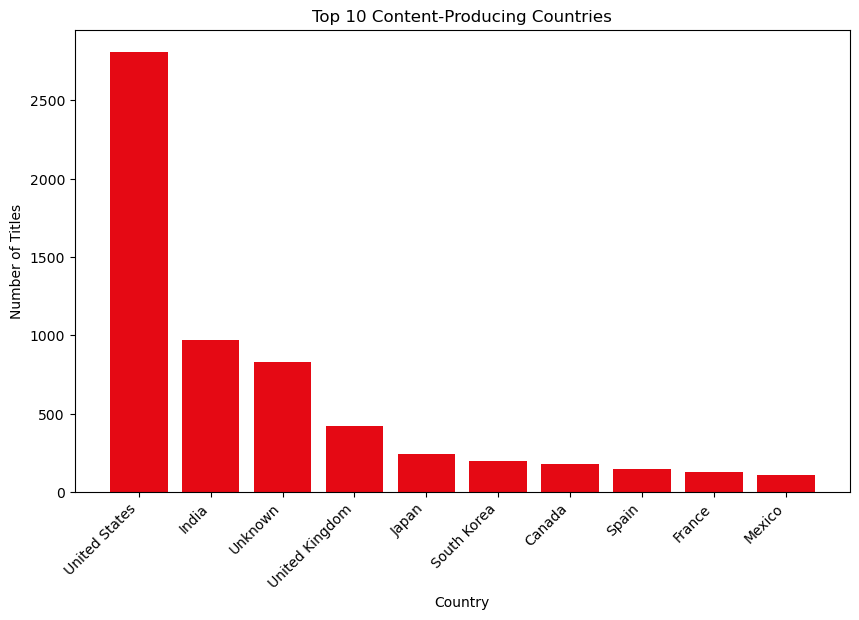

In [47]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,6))
plt.bar(top_countries.index, top_countries.values, color='#E50914')
plt.title("Top 10 Content-Producing Countries")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45, ha='right')
plt.savefig("visuals/top_10_countries.png")
plt.show()

The United States is by far the top content-producing coumtry (2,809 titles), followed by India (972) and the United Kingdom (418). 
'Unknown' ranks fourth due to missing country data filled during cleaning; worth noting this isn't a real country.

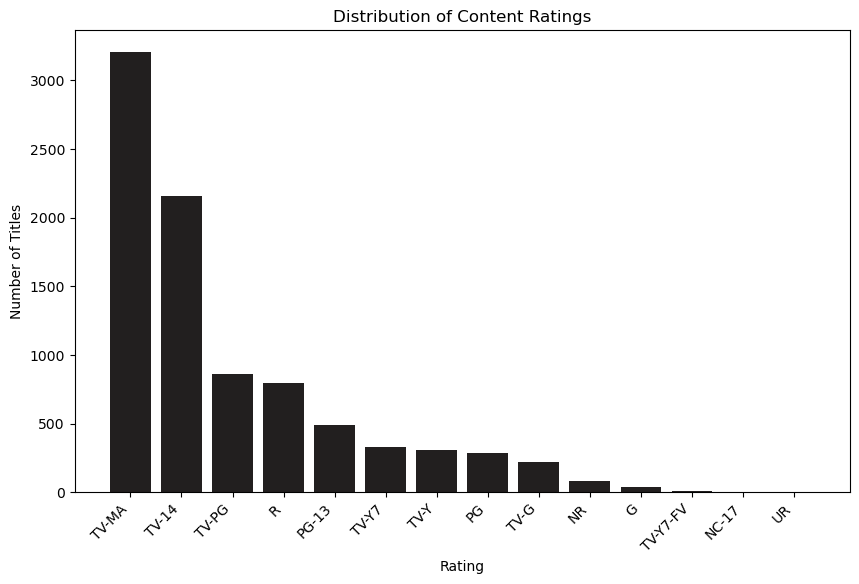

In [48]:
rating_counts = df['rating'].value_counts()

plt.figure(figsize=(10,6))
plt.bar(rating_counts.index, rating_counts.values, color='#221f1f')
plt.title("Distribution of Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45, ha='right')
plt.savefig("visuals/ratings_distribution.png")
plt.show()

TV-MA (mature audience) is the most common rating at 3,205 titles, followed by TV-14 (2,157) and TV-PG (861). This suggests Netflix's catalog leanstoward mature/adult content rather than family-friendly programming.

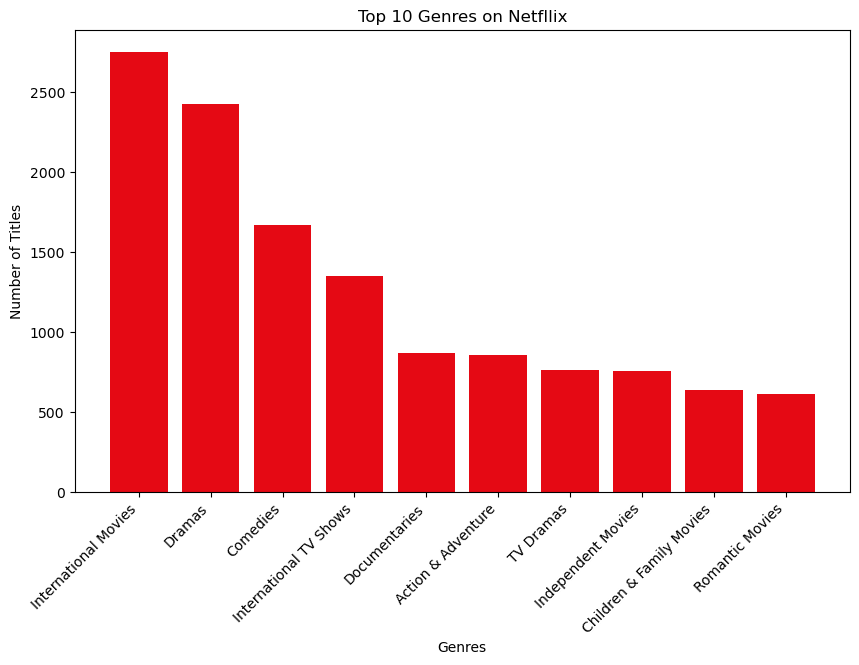

In [49]:
genre_counts = df['listed_in'].str.split(', ').explode().value_counts().head(10)

plt.figure(figsize=(10,6))
plt.bar(genre_counts.index, genre_counts.values, color='#E50914')
plt.title("Top 10 Genres on Netfllix")
plt.xlabel("Genres")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45, ha='right')
plt.savefig("visuals/top_10_genres")
plt.show()

International Movies is the most common genre (2,752), followed by Dramas (2,426) and Comedies (1,674). This reflects Netflix's strong focus on global, non-English-language content alongside core drama/comedy programming.

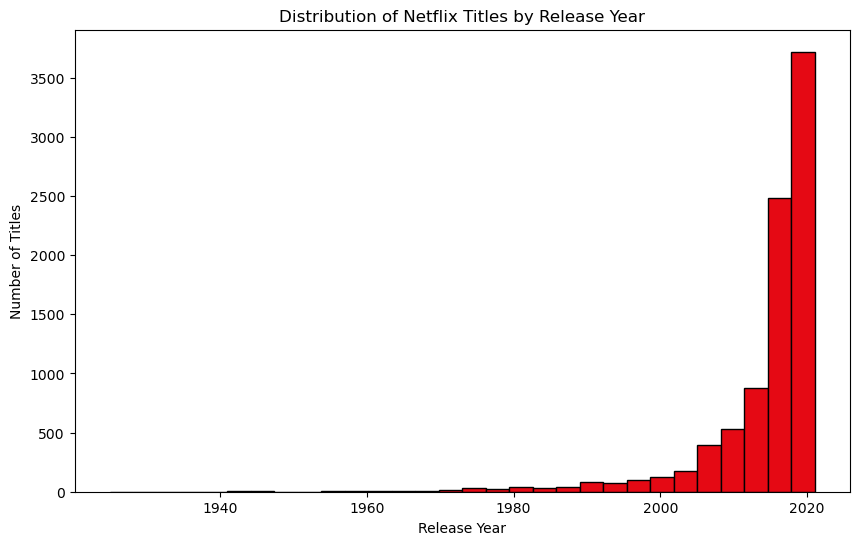

In [50]:
plt.figure(figsize=(10,6))
plt.hist(df['release_year'], bins=30, color='#E50914', edgecolor='black')
plt.title("Distribution of Netflix Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.savefig("visuals/release_year_hisogram.png")
plt.show()


The histogram confirms a heavy right skew: the vast majority of titles were released after 2010, with a sharp spike near 2018-2020. Very few titles in the catalog were released before 1980, showing that Netflix's library is overwhelmingly composed of recent content rather than older/classic titles.


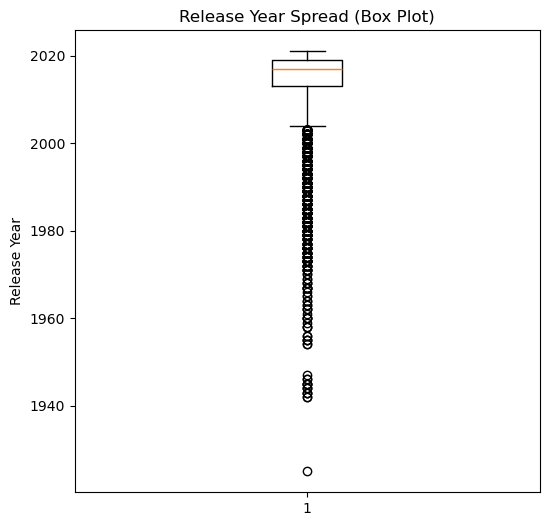

In [51]:
plt.figure(figsize=(6,6))
plt.boxplot(df['release_year'])
plt.title("Release Year Spread (Box Plot)")
plt.ylabel("Release Year")
plt.savefig("visuals/release_year_boxplot")
plt.show()

The box plot shows the median release year sits close to 2017-2018, with the interquartile range (the box) tightly clustered in recent years. Titles released before roughly 1970 appear as individual outlier points, confirming that older content makes up a very small, scattered portion of the catalog rather than a meaningful segment.

## Task 5: Key Insights

**1. Netflix's catalog is movie-dominated.**
Movies make up roughly 70% of all titles (6,126 movies vs 2,664 TV shows), as shown in the Movies vs TV Shows pie chart. This suggests Netflix's content strategy has historically prioritized film licensing/production over episodic series.

**2. Content acquisition grew explosively from 2016 to 2019.**
The line chart and histogram both show a sharp jump in titles added starting 2016 (426 titles) through a peak in 2019 (2,016 titles), before a slight decline in 2020-2021; likely tied to pandemic-related production and licensing slowdowns.

**3. The United States dominates content origin, but the catalog is genuinely global.**
The top countries bar chart shows the US contributing 2,809 titles, more than double India's 972 (the second-highest). However, the presence of India, UK, Japan, and South Korea in the top 5 shows meaningful international diversity in sourcing.

**4. The catalog skews toward mature audiences.**
TV-MA is the most common rating (3,205 titles), nearly 1.5x more than the next-highest rating (TV-14, 2,157). Combined with R-rated content (799 titles), this indicates Netflix's library leans adult-oriented rather than family-focused.

**5. International and dramatic content define Netflix's genre identity.**
The genre bar chart shows "International Movies" (2,752) and "Dramas" (2,426) as the top two genres - reinforcing the earlier finding that content sourcing is genuinely global, not just US-centric despite the country-of-origin skew.
